In [1]:
# Cellule 1 — Charger les librairies
import cv2      # OpenCV : traitement d'images
import os       # gestion des dossiers
import numpy as np  # calcul numérique (utilisé par OpenCV)

print("Librairies chargées !")

Librairies chargées !


In [2]:
# Cellule 2 — Configurer les dossiers
os.chdir("..")  # remonter vers projet_VIT_NLP/
os.makedirs("data/processed", exist_ok=True)  # créer le dossier de sortie

images = sorted(os.listdir("data/images"))
print(f"{len(images)} images à traiter")

34 images à traiter


In [4]:
# Cellule 3 — Nettoyer toutes les images avec OpenCV
for filename in images:
    # Lire l'image
    img = cv2.imread(f"data/images/{filename}")
    
    # Etape 1 : convertir en niveaux de gris (supprimer la couleur)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Etape 2 : binarisation (tout en noir ou blanc)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 10)
    
    # Etape 3 : supprimer le bruit
    clean = cv2.fastNlMeansDenoising(binary, h=10)
    
    # Sauvegarder l'image nettoyée
    cv2.imwrite(f"data/processed/{filename}", clean)
    print(f"{filename} traitée")

page_001.jpg traitée
page_002.jpg traitée
page_003.jpg traitée
page_004.jpg traitée
page_005.jpg traitée
page_006.jpg traitée
page_007.jpg traitée
page_008.jpg traitée
page_009.jpg traitée
page_010.jpg traitée
page_011.jpg traitée
page_012.jpg traitée
page_013.jpg traitée
page_014.jpg traitée
page_015.jpg traitée
page_016.jpg traitée
page_017.jpg traitée
page_018.jpg traitée
page_019.jpg traitée
page_020.jpg traitée
page_021.jpg traitée
page_022.jpg traitée
page_023.jpg traitée
page_024.jpg traitée
page_025.jpg traitée
page_026.jpg traitée
page_027.jpg traitée
page_028.jpg traitée
page_029.jpg traitée
page_030.jpg traitée
page_031.jpg traitée
page_032.jpg traitée
page_033.jpg traitée
page_034.jpg traitée


34 images traitées dans data/processed/


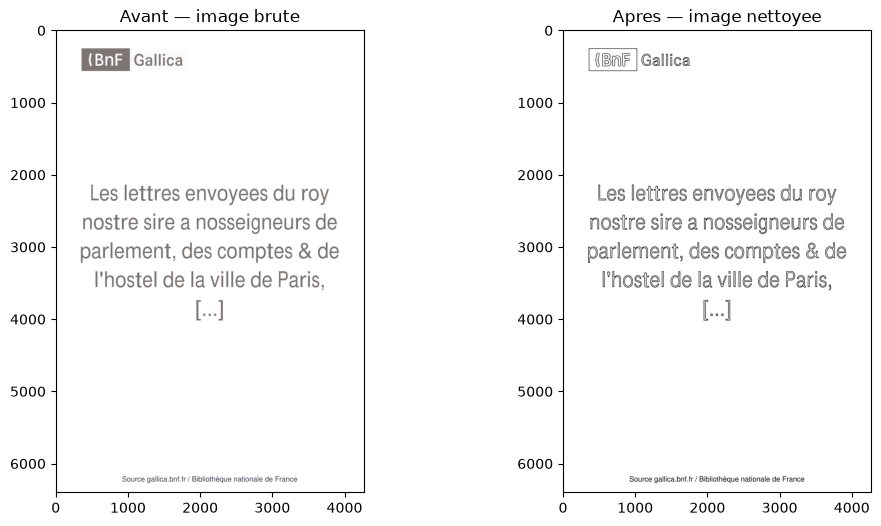

In [5]:
# Cellule 4 — Vérifier le résultat
processed = os.listdir("data/processed")
print(f"{len(processed)} images traitées dans data/processed/")

import matplotlib.pyplot as plt

avant = cv2.imread("data/images/page_001.jpg")
apres = cv2.imread("data/processed/page_001.jpg")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(cv2.cvtColor(avant, cv2.COLOR_BGR2RGB))
ax1.set_title("Avant — image brute")
ax2.imshow(apres, cmap="gray")
ax2.set_title("Apres — image nettoyee")
plt.show()